## 1D CNN on tabular data:

- treat each sample as a 1D feature vector
- reshape from (num_samples, num_features) to (num_samples, num_features, 1)
- use Conv1D + ReLU + pooling + dense layers
- train with cross-entropy loss
- track:
    - accuracy
    - precision / recall / F1
    - confusion matrix
    - loss vs epoch
    - accuracy vs epoch

In [41]:
%pip install numpy pandas matplotlib scikit-learn tensorflow ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

In [43]:
covertype = fetch_ucirepo(id=31)

X = covertype.data.features.copy()
y = covertype.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())

X shape: (581012, 54)
y shape: (581012,)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0


0    5
1    5
2    2
3    2
4    5
Name: Cover_Type, dtype: int64

Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


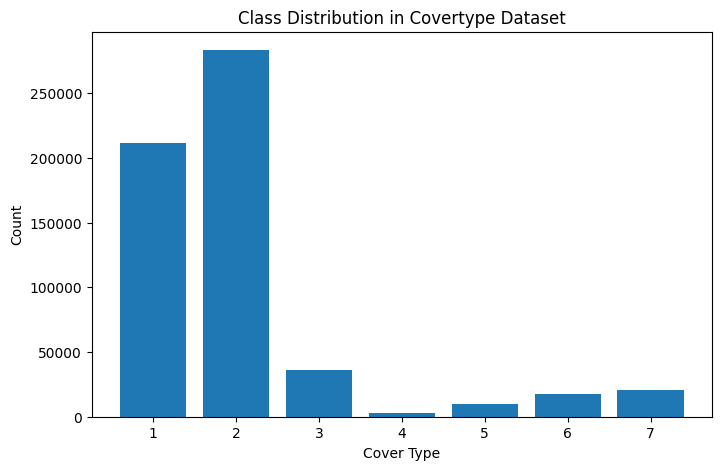

In [44]:
class_counts = y.value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.title("Class Distribution in Covertype Dataset")
plt.show()

In [45]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (406707, 54)
Validation shape: (58102, 54)
Test shape: (116203, 54)


In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [47]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("CNN train shape:", X_train_cnn.shape)

CNN train shape: (406707, 54, 1)


In [48]:
y_train_encoded = to_categorical(y_train - 1, num_classes=7)
y_val_encoded = to_categorical(y_val - 1, num_classes=7)
y_test_encoded = to_categorical(y_test - 1, num_classes=7)

In [49]:
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\vasup\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 52, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 52, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 24, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,247 (227.53 KB)

 Trainable params: 58,055 (226.78 KB)

 Non-trainable params: 192 (768.00 B)

In [50]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [51]:
history = model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.6896 - loss: 0.7345 - val_accuracy: 0.7552 - val_loss: 0.5622
Epoch 2/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.7505 - loss: 0.5892 - val_accuracy: 0.7776 - val_loss: 0.5115
Epoch 3/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7666 - loss: 0.5461 - val_accuracy: 0.7921 - val_loss: 0.4776
Epoch 4/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.7791 - loss: 0.5184 - val_accuracy: 0.7998 - val_loss: 0.4590
Epoch 5/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7882 - loss: 0.4999 - val_accuracy: 0.8078 - val_loss: 0.4480
Epoch 6/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.7935 - loss: 0.4860 - val_accuracy: 0.8102 - val_loss: 0.4390
Epoch 7/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7988 - loss: 0.4745 - val_accuracy: 0.8171 - val_loss: 0.4259
Epoch 8/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8034 -

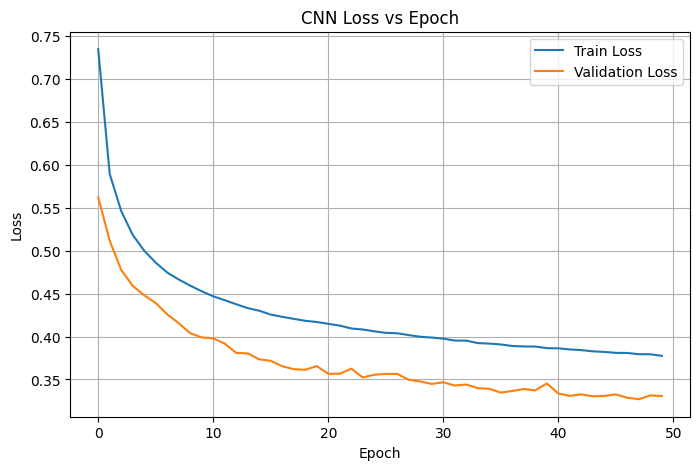

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

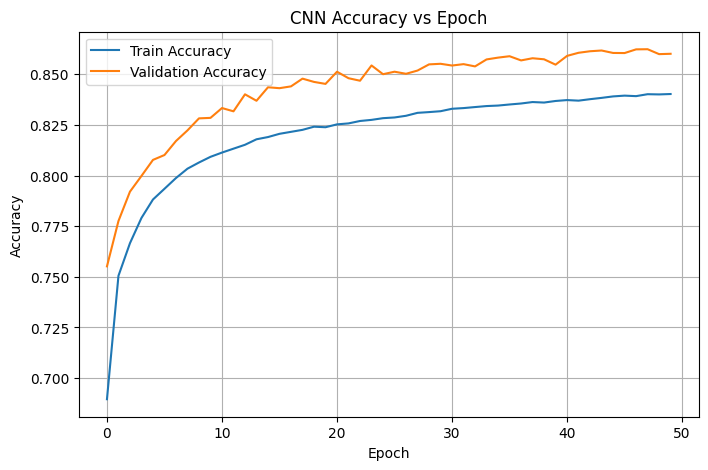

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_encoded, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.32617393136024475
Test Accuracy: 0.864203155040741


In [55]:
y_test_prob = model.predict(X_test_cnn)
y_test_pred = np.argmax(y_test_prob, axis=1) + 1

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step


In [56]:
test_precision_macro = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

test_precision_weighted = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall_weighted = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_weighted = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Test Precision (Macro):", test_precision_macro)
print("Test Recall (Macro):", test_recall_macro)
print("Test F1-score (Macro):", test_f1_macro)
print("Test Precision (Weighted):", test_precision_weighted)
print("Test Recall (Weighted):", test_recall_weighted)
print("Test F1-score (Weighted):", test_f1_weighted)

Test Precision (Macro): 0.8437418548522715
Test Recall (Macro): 0.705313562623151
Test F1-score (Macro): 0.7525852216788274
Test Precision (Weighted): 0.8643470342870999
Test Recall (Weighted): 0.8642031617083896
Test F1-score (Weighted): 0.8615419398270909


In [57]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.88      0.85      0.87     42368
           2       0.87      0.91      0.89     56661
           3       0.78      0.89      0.83      7151
           4       0.87      0.53      0.66       549
           5       0.87      0.39      0.54      1899
           6       0.72      0.55      0.62      3473
           7       0.93      0.82      0.87      4102

    accuracy                           0.86    116203
   macro avg       0.84      0.71      0.75    116203
weighted avg       0.86      0.86      0.86    116203



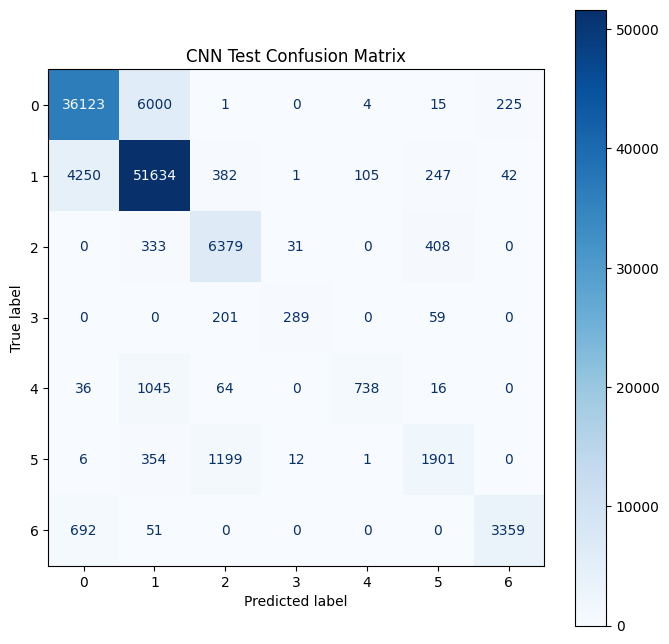

In [58]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("CNN Test Confusion Matrix")
plt.show()

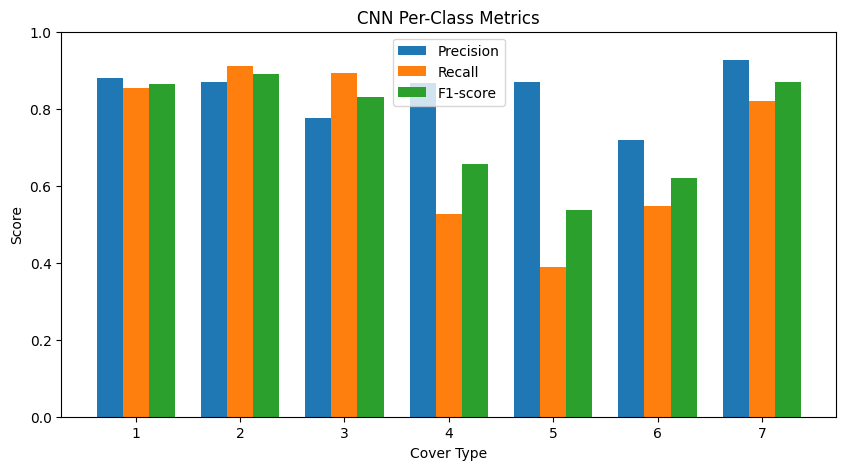

In [59]:
report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)

classes = [str(i) for i in sorted(y.unique())]
precisions = [report[c]["precision"] for c in classes]
recalls = [report[c]["recall"] for c in classes]
f1s = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precisions, width=width, label="Precision")
plt.bar(x, recalls, width=width, label="Recall")
plt.bar(x + width, f1s, width=width, label="F1-score")

plt.xticks(x, classes)
plt.xlabel("Cover Type")
plt.ylabel("Score")
plt.title("CNN Per-Class Metrics")
plt.ylim(0, 1)
plt.legend()
plt.show()